## WildGuardMix EDA

[TODO] name, source, overview


### Load Dependencies and Data

In [40]:
# Dependencies

import pandas as pd
import matplotlib.pyplot as plt
from pyprojroot import here

# Project path anchors
REPO_ROOT = here()
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = REPO_ROOT / "data" / "processed"
MODEL_DIR = REPO_ROOT / "data" / "models"


In [41]:
# Load Data
train_file = RAW_DATA_DIR / "wildguardmix" / "train" / "wildguard_train.parquet"
test_file = RAW_DATA_DIR / "wildguardmix" / "test" / "wildguard_test.parquet"
final_file = PROCESSED_DATA_DIR / "wildguardmix_single_turn.parquet"

df_train = pd.read_parquet(train_file)
df_test = pd.read_parquet(test_file)

# Add source column
df_train["source_split"] = "train"
df_test["source_split"] = "test"

# Combine for EDA
combined = pd.concat([df_train, df_test], ignore_index=True)


### Review the overall data

In [42]:
# View Overall Structure
combined.info()


<class 'pandas.DataFrame'>
RangeIndex: 88484 entries, 0 to 88483
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   prompt                      88484 non-null  str    
 1   adversarial                 88484 non-null  bool   
 2   response                    39659 non-null  str    
 3   prompt_harm_label           88458 non-null  str    
 4   response_refusal_label      39696 non-null  str    
 5   response_harm_label         39685 non-null  str    
 6   subcategory                 88484 non-null  str    
 7   source_split                88484 non-null  str    
 8   response_refusal_agreement  1720 non-null   float64
 9   prompt_harm_agreement       1699 non-null   float64
 10  response_harm_agreement     1709 non-null   float64
dtypes: bool(1), float64(3), str(7)
memory usage: 117.6 MB


In [43]:
# Get a sense of the category columns removing the agreement columns

label_columns = ['adversarial', 'prompt_harm_label', 'response_refusal_label', 'response_harm_label', 'subcategory']

print(f"Training Data Columns: {label_columns}\n")

for col in label_columns:
    if col in combined.columns:
        
        unique_vals = combined[col].dropna().unique()
        num_categories = len(unique_vals)

        category_counts = combined[col].value_counts().to_dict()

        print(f"Column Name: {col}")
        print(f"  Total Categories: {num_categories}")
        print(f"  Type of Categories: {combined[col].dtype}")

        print(f"  Exact Categories and Numbers: {category_counts}")
        print("-" * 50)

Training Data Columns: ['adversarial', 'prompt_harm_label', 'response_refusal_label', 'response_harm_label', 'subcategory']

Column Name: adversarial
  Total Categories: 2
  Type of Categories: bool
  Exact Categories and Numbers: {False: 46718, True: 41766}
--------------------------------------------------
Column Name: prompt_harm_label
  Total Categories: 2
  Type of Categories: str
  Exact Categories and Numbers: {'harmful': 46970, 'unharmful': 41488}
--------------------------------------------------
Column Name: response_refusal_label
  Total Categories: 2
  Type of Categories: str
  Exact Categories and Numbers: {'compliance': 20145, 'refusal': 19551}
--------------------------------------------------
Column Name: response_harm_label
  Total Categories: 2
  Type of Categories: str
  Exact Categories and Numbers: {'unharmful': 31018, 'harmful': 8667}
--------------------------------------------------
Column Name: subcategory
  Total Categories: 15
  Type of Categories: str
  Exac

### Narrow the dataset to what we need

In [44]:
# Focus the data into the columns that we will use to train the model: prompt, response, prompt-harm-label, and response-refusal-label
combined_col = combined[['prompt', 'response','prompt_harm_label', 'response_refusal_label', 'adversarial', 'subcategory', 'source_split' ]]

In [45]:
# Quality preflight check
combined_col.info()


<class 'pandas.DataFrame'>
RangeIndex: 88484 entries, 0 to 88483
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   prompt                  88484 non-null  str  
 1   response                39659 non-null  str  
 2   prompt_harm_label       88458 non-null  str  
 3   response_refusal_label  39696 non-null  str  
 4   adversarial             88484 non-null  bool 
 5   subcategory             88484 non-null  str  
 6   source_split            88484 non-null  str  
dtypes: bool(1), str(6)
memory usage: 114.6 MB


### Check Quality and Remove Non-essential Data

In [46]:
# Our final dataset requires a prompt + response (single turn) and a prompt harm label
combined_final = combined_col[combined_col['response'].notna()].copy()

# Check to see what rows dont have data
combined_final.isna().sum()


prompt                     0
response                   0
prompt_harm_label         26
response_refusal_label     5
adversarial                0
subcategory                0
source_split               0
dtype: int64

In [47]:
# Remove rows that don't have a prompt harm label (26 of them)
combined_final = combined_final[combined_final['prompt_harm_label'].notna()].copy()

# Add a unknown for the 5 empty prompt refusal rows since it's not material, but additive, to our overall model
combined_final["response_refusal_label"] = (
    combined_final["response_refusal_label"].fillna("unknown")
)

### Review Distributions and Look for Imbalances

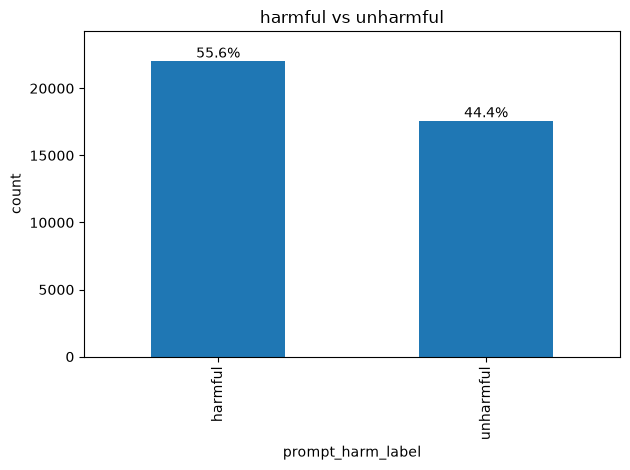

In [48]:
# Calculate the distributions to show on the graph
counts = combined_final['prompt_harm_label'].value_counts()
pct = counts / counts.sum() * 100

# Show distribution of harmful vs unharmful
ax = counts.plot(kind="bar", title="harmful vs unharmful")
for i, (n, p) in enumerate(zip(counts, pct)):
    ax.text(i, n, f"{p:.1f}%", ha="center", va="bottom")
ax.set_ylabel("count")
ax.margins(y=.1)
plt.tight_layout()
plt.show()

adversarial        False  True 
prompt_harm_label              
harmful             56.9   43.1
unharmful           47.1   52.9


<Axes: title={'center': 'adversarial vs vanilla, by harm class'}, xlabel='prompt_harm_label'>

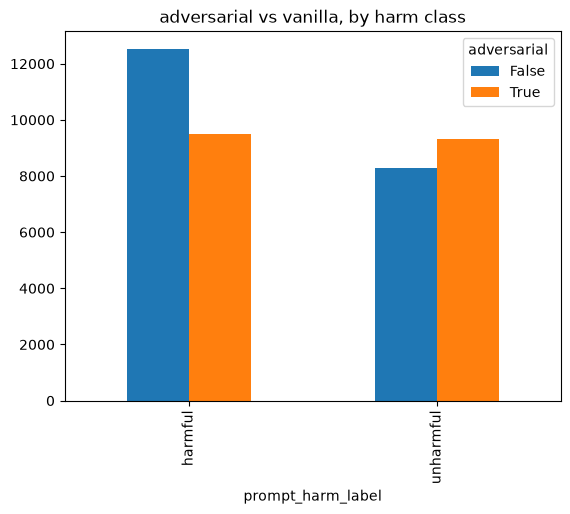

In [49]:
# Determine whether or not adversarial phrases predict harm
print(pd.crosstab(combined_final['prompt_harm_label'], combined_final['adversarial'],
            normalize="index").mul(100).round(1))

# Show adversarial grouping by harm
ct = pd.crosstab(combined_final['prompt_harm_label'], combined_final['adversarial'])
ct.plot(kind="bar", title="adversarial vs vanilla, by harm class") 

In [50]:
# Determine if the length is a potential signal
combined_final['prompt_length'] = combined_final['prompt'].str.split().str.len()
combined_final['response_length'] = combined_final['response'].str.split().str.len()

# Describe by class as a quick comparison
combined_final.groupby('prompt_harm_label')[['prompt_length', 'response_length']].describe()

prompt_length                                                \
                          count       mean        std  min   25%   50%    75%   
prompt_harm_label                                                               
harmful                 22040.0  80.209846  76.181024  4.0  20.0  36.0  129.0   
unharmful               17593.0  70.748821  67.646365  2.0  11.0  65.0  115.0   

                         response_length                                     \
                     max           count        mean         std  min   25%   
prompt_harm_label                                                             
harmful            651.0         22040.0  277.230581  242.520221  1.0  86.0   
unharmful          536.0         17593.0  248.037174  199.995255  1.0  95.0   

                                         
                     50%    75%     max  
prompt_harm_label                        
harmful            210.0  408.0  1685.0  
unharmful          208.0  346.0  1578.0

In [51]:
# See how many of the prompts are unique
print(f"Total Number of Unique Prompts: {combined_final["prompt"].nunique()}")

Total Number of Unique Prompts: 20321


In [52]:
# Save final process file to the processed folder
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
combined_final.to_parquet(final_file, index=False)

### Takeaways and integration into the final schema



The final dataset has 39,633 single-turn rows.
Schema:
- Prompt: Initial Prompt (string)
- Response: Response to the Prompt (string)
- Harm Label: harmful or unharmful classification based on the prompt
- Adversarial: True or False based on a human assessment of the prompt
- Response Refusal Label: 
- Subcategory: 
- Source Split: Train or Test from original dataset (metadata)

Cleaning Decisions
- Dropped prompt-only rows (ones with no response) because it's out of scope for our project
- Dropped 26 rows with no prompt harm label because it's not useful for our project
- Filled in 5 missing response refusal labels with unknown for completeness (useful metadata)


